# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [5]:
# Import the four packages here.
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path

## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [6]:
boundary_path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"
# Read the boundary.
maine_boundary = gpd.read_file("../labs/ME_ShapeFiles/Maine_State_Boundary.shp")

# Print its CRS and shape.
print(maine_boundary.shape)
print(maine_boundary.crs)

# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()

maine_boundary

(6204, 10)
EPSG:4326


,geometry,OBJECTID,LAND,GlobalID,created_us,created_da,last_edite,last_edi_1,Shape__Are,Shape__Len
0,"MULTIPOLYGON (((-70.60685 42.97751, -70.60673 ...",1,y,25ab82ef-ffa7-4098-a01a-01a5c1dfc6fc,Emily.Pettit@maine.gov_maine,2021-08-02,Emily.Pettit@maine.gov_maine,2021-08-02,8.302555e+10,5.736060e+06


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [7]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_1.tif",
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [8]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims)
print("Shape:", bio1.shape)
print("Data type:", bio1.dtype)
print("CRS:", bio1.rio.crs)
print("Resolution:", bio1.rio.resolution())
print("Bounds:", bio1.rio.bounds())
print("NoData:", bio1.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [9]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [11]:
# Compare global and clipped metadata here.
print("Global shape:", bio1.shape)
print("Maine shape:", bio1_maine.shape)
print("Global CRS:", bio1.rio.crs)
print("Maine CRS:", bio1_maine.rio.crs)
print("Global Bounds:", bio1.rio.bounds())
print("Maine bounds:", bio1_maine.rio.bounds())
print("Global Resolution:", bio1.rio.resolution())
print("Maine resolution:", bio1_maine.rio.resolution())

Global shape: (1, 4320, 8640)
Maine shape: (109, 101)
Global CRS: EPSG:4326
Maine CRS: EPSG:4326
Global Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
Maine bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
Global Resolution: (0.041666666666666664, -0.041666666666666664)
Maine resolution: (0.04166666666666671, -0.041666666666666664)


**Your comparison:** The shape and bounds change, the CRS and resolution stay the same

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

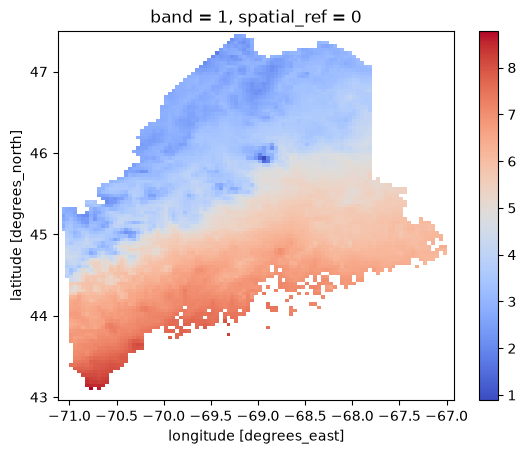

In [12]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="coolwarm")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** Bio_12 Annual precipitation. I would want to know this becasue precipitation can be a predictor for mushroom fruiting, and for our amphibian data may impact occurences becasue amphibians perfer moist environments

**Variable 2 and justification:** BIO16 = Precipitation of Wettest Quarter, similar to the justification above, I would be curious to see the precipitation in a wet extreme season to see how it effects amphibian occurance

**Variable 3 and justification:** BIO17 = Precipitation of Driest Quarter, I am choosing this as the other extreme to the above choice, I want to see how precipitation in the driest quarter effects amphibian occurance

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [13]:
# Open your first additional raster.
bio12 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_12.tif",
    masked=True,
)
# Inspect its metadata.
print("Dimensions:", bio12.dims)
print("Shape:", bio12.shape)
print("Data type:", bio12.dtype)
print("CRS:", bio12.rio.crs)
print("Resolution:", bio12.rio.resolution())
print("Bounds:", bio12.rio.bounds())
print("NoData:", bio12.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [14]:
# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio12.rio.crs)
print("Same shape:", bio1.shape == bio12.shape)
print("Same resolution:", bio1.rio.resolution() == bio12.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio12.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

In [16]:
# Clip, squeeze, and plot the first additional raster. 
bio12_maine = bio12.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio12_maine = bio12_maine.squeeze()


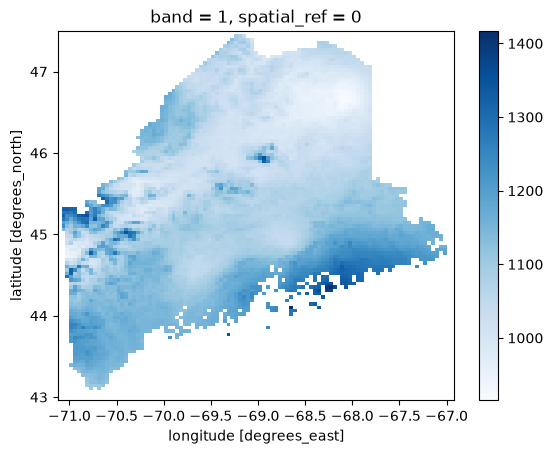

In [17]:
bio12_maine.plot(cmap="Blues")

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

In [ ]:
# Complete the workflow for the second additional raster.

In [18]:
# Open your second additional raster.
bio16 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_16.tif",
    masked=True,
)
# Inspect its metadata.
print("Dimensions:", bio16.dims)
print("Shape:", bio16.shape)
print("Data type:", bio16.dtype)
print("CRS:", bio16.rio.crs)
print("Resolution:", bio16.rio.resolution())
print("Bounds:", bio16.rio.bounds())
print("NoData:", bio16.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


In [20]:
# Compare the second additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio16.rio.crs)
print("Same shape:", bio1.shape == bio16.shape)
print("Same resolution:", bio1.rio.resolution() == bio16.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio16.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


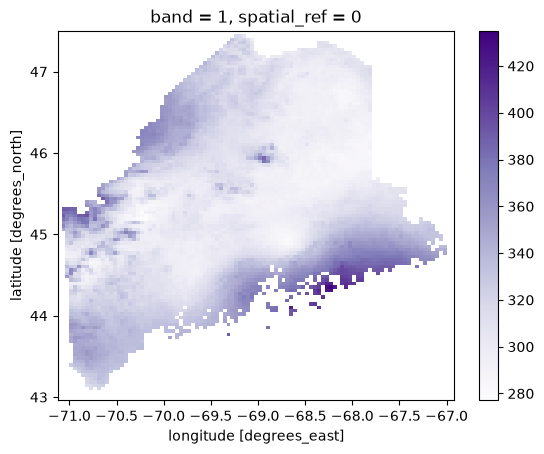

In [25]:
# Clip, squeeze, and plot the second additional raster. 
bio16_maine = bio16.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio16_maine = bio16_maine.squeeze()

bio16_maine.plot(cmap="Purples")

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

In [ ]:
# Complete the workflow for the third additional raster.

In [23]:
# Open your third additional raster.
bio17 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_17.tif",
    masked=True,
)
# Inspect its metadata.
print("Dimensions:", bio17.dims)
print("Shape:", bio17.shape)
print("Data type:", bio17.dtype)
print("CRS:", bio17.rio.crs)
print("Resolution:", bio17.rio.resolution())
print("Bounds:", bio17.rio.bounds())
print("NoData:", bio17.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


In [24]:
# Compare the third additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio17.rio.crs)
print("Same shape:", bio1.shape == bio17.shape)
print("Same resolution:", bio1.rio.resolution() == bio17.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio17.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


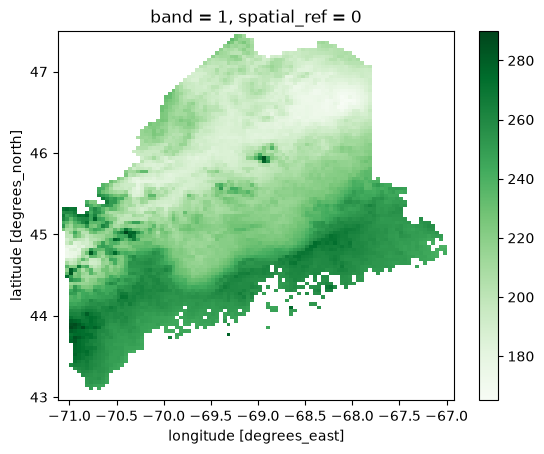

In [26]:
# Clip, squeeze, and plot the third additional raster. 
bio17_maine = bio17.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio17_maine = bio17_maine.squeeze()

bio17_maine.plot(cmap="Greens")

In [28]:
#Confirm the clipped rasters are aligned
print(bio1_maine.shape)
print(bio12_maine.shape)
print(bio16_maine.shape)
print(bio17_maine.shape)


(109, 101)
(109, 101)
(109, 101)
(109, 101)


## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [29]:
amphibians = pd.read_csv(
    "Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

# Keep the five requested columns.
columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "year",
]

amphibians = amphibians[columns_to_keep]
amphibians.shape

(25972, 5)

## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [30]:
# Convert both coordinate columns with pd.to_numeric().
amphibians["decimalLongitude"] = pd.to_numeric(
    amphibians["decimalLongitude"], errors="coerce"
)
amphibians["decimalLatitude"] = pd.to_numeric(
    amphibians["decimalLatitude"], errors="coerce"
)
# Drop rows missing species, longitude, or latitude.
amphibians = amphibians.dropna(
    subset=["species", "decimalLongitude", "decimalLatitude"]
).copy()

amphibians.shape

(25586, 5)

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [31]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1:** Aquarana clamitans

**Species 2:** Plethodon cinereus

**Species 3:** Pseudacris crucifer

In [33]:
selected_species = [
    "Aquarana clamitans",
    "Plethodon cinereus",
    "Pseudacris crucifer",
]

# Filter the occurrence table with .isin(selected_species).
selected_species= amphibians[amphibians['species'].isin(selected_species)]

selected_species.head()

,gbifID,species,decimalLongitude,decimalLatitude,year
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026.0


## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [45]:
# Create selected_amphibians_gdf here.
selected_species_gdf = gpd.GeoDataFrame(
    selected_species,
    geometry=gpd.points_from_xy(
        selected_species["decimalLongitude"],
        selected_species["decimalLatitude"],
    ),
    crs= "EPSG:4326",
)

selected_species_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0,POINT (-69.64901 44.73571)
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0,POINT (-68.70405 44.78842)
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0,POINT (-70.85036 44.27281)
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431)
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026.0,POINT (-70.39902 43.93488)


## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [46]:
# Print both coordinate systems.
print(selected_species_gdf.crs)
print(bio1_maine.rio.crs)

EPSG:4326
EPSG:4326


**Your explanation:** Matching coordinate systems are required before extracting raster values

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [47]:
# Create point_x from point longitude.
point_x = xr.DataArray(
    selected_species_gdf.geometry.x.to_numpy(),
    dims="record",
)
# Create point_y from point latitude.
point_y = xr.DataArray(
    selected_species_gdf.geometry.y.to_numpy(),
    dims="record",
)

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [48]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_species_gdf["bio1_mean_temp_c"] = bio1_values
selected_species_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0,POINT (-69.64901 44.73571),6.332833
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0,POINT (-68.70405 44.78842),6.634333
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0,POINT (-70.85036 44.27281),6.033667
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026.0,POINT (-70.39902 43.93488),6.888000


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [49]:
# Count missing extracted BIO1 values.
selected_species_gdf["bio1_mean_temp_c"].isna().value_counts()

bio1_mean_temp_c
False    7612
True     1019
Name: count, dtype: int64

**Your explanation:** They may be assigned NoData becasue raster cells are much larger and less detailed cloaser to the coast than they are at state boundary. This often happens when a point is near a NoData cell

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [50]:
# Extract values from the first additional clipped raster.
bio12_values = bio12_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_species_gdf["bio12_Annual_Precip_mm"] = bio12_values

In [51]:
# Extract values from the second additional clipped raster.
bio16_values = bio16_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
# Add the values to selected_amphibians_gdf.
selected_species_gdf["bio16_Precip_wet_quart_mm"] = bio16_values

In [52]:
# Extract values from the third additional clipped raster.
bio17_values = bio17_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
# Add the values to selected_amphibians_gdf.
selected_species_gdf["bio17_Precip_dry_quart_mm"] = bio17_values

## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [53]:
# Create and display occurrence_environment.
occurrence_environment = selected_species_gdf.drop(columns="geometry")

occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_mean_temp_c,bio12_Annual_Precip_mm,bio16_Precip_wet_quart_mm,bio17_Precip_dry_quart_mm
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0,6.332833,294.0,294.0,213.0
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0,6.634333,304.0,304.0,248.0
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0,6.033667,314.0,314.0,244.0
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,6.875500,332.0,332.0,258.0
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026.0,6.888000,337.0,337.0,259.0


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [54]:
# Calculate species-level summaries here.
predictor_columns = [
    "bio1_mean_temp_c",
    "bio12_Annual_Precip_mm",
    "bio16_Precip_wet_quart_mm",
    "bio17_Precip_dry_quart_mm",
]

for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].mean())

Aquarana clamitans 2966 
 bio1_mean_temp_c               6.381768
bio12_Annual_Precip_mm       333.721859
bio16_Precip_wet_quart_mm    333.721859
bio17_Precip_dry_quart_mm    241.461874
dtype: float64
Plethodon cinereus 2864 
 bio1_mean_temp_c               6.868341
bio12_Annual_Precip_mm       344.158899
bio16_Precip_wet_quart_mm    344.158899
bio17_Precip_dry_quart_mm    247.253884
dtype: float64
Pseudacris crucifer 2801 
 bio1_mean_temp_c               6.551031
bio12_Annual_Precip_mm       327.923992
bio16_Precip_wet_quart_mm    327.923992
bio17_Precip_dry_quart_mm    241.867562
dtype: float64


## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [55]:
# Select the four predictor columns and calculate .corr().
occurrence_environment[predictor_columns].corr().round(2)

,bio1_mean_temp_c,bio12_Annual_Precip_mm,bio16_Precip_wet_quart_mm,bio17_Precip_dry_quart_mm
bio1_mean_temp_c,1.00,0.34,0.34,0.71
bio12_Annual_Precip_mm,0.34,1.00,1.00,0.64
bio16_Precip_wet_quart_mm,0.34,1.00,1.00,0.64
bio17_Precip_dry_quart_mm,0.71,0.64,0.64,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning. Bio1 and Bio17 have a decently high correlation. In this case, I do not think the correlation is high enough to seperate the two predictors into seperate models. 

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [56]:
# Save occurrence_environment with .to_csv().
occurrence_environment.to_csv(
    "Assignment05_environmental_values.csv",
    index=False,
)

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact?
Raster resolution sets the size of the 'box' that an occurence coordinate can be located in. Finer resolution offers more spatial variation, and as long as the uncertainty for your point falls under hte range of the cell size, you do not have to worry. 
2. What environmental variation is lost when all occurrences in one raster cell receive the same value? All variation within the same cell si lost, as the raster cell is a summary of the climatic variable for that area. Resolution can chnage the cell size which may recover some variation, but within cell variaiton will always be lost. 
3. Which predictor has the strongest biological justification for your selected species? Annual precipitation. For many amphibian species, they rely on water for reproduction, so it is useful to see how occurance data chnages in drier verus wetter years. 
4. Which preprocessing choice is most important to document for reproducibility?
I think that checking the CRS is the most important thing to document for repoducibility. This is because all data needs to be in the same CRS system for the anlysis to run properly,and if you are doing large datasets over the course of multipel weeks you ened ot make sure the CRS is the same for all. 
5. Name one additional environmental predictor you would seek for an amphibian study and explain why. Another variable I would choose would be Temperature seasonality because many amphibians are season creatures, and the temeprature for a given season may influence when they emerge from winter  and therefore influence when occurence data is collected

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```